| Feature          | FAISS                          | Chroma                             | Pinecone                                             |
| ---------------- | ------------------------------ | ---------------------------------- | ---------------------------------------------------- |
| Product type     | Vector-search library          | Vector database                    | Managed vector database                              |
| Runs locally     | Yes                            | Yes                                | No normal local database mode                        |
| Managed cloud    | No                             | Yes                                | Yes, primary mode                                    |
| Vector index     | Directly controlled            | Database-managed                   | Fully managed                                        |
| Documents        | LangChain/external store       | Native collection record           | Metadata/document fields through records/integration |
| Metadata         | External/wrapper               | Native                             | Native                                               |
| Metadata filters | Not native FAISS DB filtering  | Native                             | Native                                               |
| CRUD             | Limited/index-dependent        | Native                             | Native                                               |
| Persistence      | Manual save/load               | Automatic persistent client/server | Managed                                              |
| Collections      | No native collection primitive | Native collections                 | Indexes and namespaces                               |
| Scaling          | You design it                  | Local/server/cloud options         | Automatically managed infrastructure                 |
| Server API       | Build yourself                 | Available                          | Built-in                                             |
| GPU/index tuning | Strong direct control          | Abstracted                         | Fully abstracted                                     |
| Cost             | Infrastructure only            | Local free/cloud paid              | Cloud usage-based                                    |
| Best for         | Research/local/custom ANN      | Local RAG and flexible deployments | Production cloud-scale retrieval                     |


In [1]:
import os
import time
from uuid import uuid4
from dotenv import load_dotenv
from pinecone import Pinecone, ServerlessSpec
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langchain_core.documents import Document


/Users/rakhi/Documents/AI/AgenticAI/Practical/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ---------------------------------------------------
# 1. Load environment variables
# ---------------------------------------------------

load_dotenv()

#openai_api_key = os.getenv("OPENAI_API_KEY")
gemi_api_key = os.getenv("GOOGLE_API_KEY")
pinecone_api_key = os.getenv("PINECONE_API_KEY")

# if not openai_api_key:
#     raise ValueError("OPENAI_API_KEY is missing")

if not gemi_api_key:
    raise ValueError("GEMINI_API_KEY is missing")

if not pinecone_api_key:
    raise ValueError("PINECONE_API_KEY is missing")


In [ ]:
# ---------------------------------------------------
# 2. Embedding model
# ---------------------------------------------------


# from langchain_openai import OpenAIEmbeddings
# embeddings=OpenAIEmbeddings(model="text-embedding-3-large")


from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

dimension = len(
    embeddings.embed_query("dimension check")
)
print("Embedding dimension:", dimension)



Embedding dimension: 384


In [17]:
# ---------------------------------------------------
# 3. Pinecone client
# ---------------------------------------------------
pc = Pinecone(
    api_key=pinecone_api_key
)

index_name = "langchain-llama-index"


In [8]:
# ---------------------------------------------------
# 4. Create index
# ---------------------------------------------------

if not pc.has_index(index_name):
    pc.create_index(
        name=index_name,
        dimension=dimension,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        ),
    )

In [10]:
# ---------------------------------------------------
# 5. Wait for index readiness
# ---------------------------------------------------
while True:
    description = pc.describe_index(index_name)
    if description.status["ready"]:
        break
    time.sleep(2)

In [11]:
# ---------------------------------------------------
# 6. Connect to index
# ---------------------------------------------------
index = pc.Index(index_name)

In [ ]:
# ---------------------------------------------------
# 7. LangChain Pinecone vector store
# ---------------------------------------------------

vector_store = PineconeVectorStore(
    index=index,
    embedding=embeddings,
    namespace="demo-documents"
)

# Namespace is a way to partition your data in Pinecone. 
# You can think of it as a "folder" or "bucket" where you can store related vectors. 
# By using namespaces, you can organize your data and avoid collisions between different datasets.

In [13]:
# ---------------------------------------------------
# 8. Create documents
# ---------------------------------------------------

documents = [
    Document(
        page_content=(
            "I had chocolate chip pancakes and "
            "scrambled eggs for breakfast this morning."
        ),
        metadata={"source": "tweet"},
    ),
    Document(
        page_content=(
            "The weather forecast for tomorrow is cloudy "
            "and overcast, with a high of 62 degrees."
        ),
        metadata={"source": "news"},
    ),
    Document(
        page_content=(
            "Building an exciting new project with "
            "LangChain - come check it out!"
        ),
        metadata={"source": "tweet"},
    ),
    Document(
        page_content=(
            "Robbers broke into the city bank and "
            "stole $1 million in cash."
        ),
        metadata={"source": "news"},
    ),
    Document(
        page_content=(
            "LangGraph is the best framework for building "
            "stateful, agentic applications!"
        ),
        metadata={"source": "tweet"},
    ),
]

ids = [
    str(uuid4())
    for _ in documents
]


In [14]:
# ---------------------------------------------------
# 9. Add documents
# ---------------------------------------------------

inserted_ids = vector_store.add_documents(
    documents=documents,
    ids=ids
)

print("Inserted IDs:", inserted_ids)


Inserted IDs: ['64f4b505-0040-4f78-84b2-db4ecf3eb789', 'd686732c-c3f7-422e-b455-644c136e42b0', '3cd90da6-db21-4a97-87f6-e595c104201d', 'cb471a3e-589d-4048-b8d7-1d5e678b5dec', '8b52915c-c17f-4599-90ad-c29e5c12247f']


In [15]:
# ---------------------------------------------------
# 10. Similarity search with metadata filter
# ---------------------------------------------------

results = vector_store.similarity_search(
    query=(
        "LangChain provides abstractions "
        "for working with LLMs"
    ),
    k=2,
    filter={
        "source": "tweet"
    }
)

for result in results:
    print(result.page_content)
    print(result.metadata)


Building an exciting new project with LangChain - come check it out!
{'source': 'tweet'}
LangGraph is the best framework for building stateful, agentic applications!
{'source': 'tweet'}


In [16]:
# ---------------------------------------------------
# 11. Retriever with threshold and filter
# ---------------------------------------------------

retriever = vector_store.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={
        "k": 1,
        "score_threshold": 0.4,
        "filter": {
            "source": "news"
        }
    }
)

retrieved_docs = retriever.invoke(
    "Stealing money from a bank is a crime"
)

print(retrieved_docs)


[Document(id='cb471a3e-589d-4048-b8d7-1d5e678b5dec', metadata={'source': 'news'}, page_content='Robbers broke into the city bank and stole $1 million in cash.')]


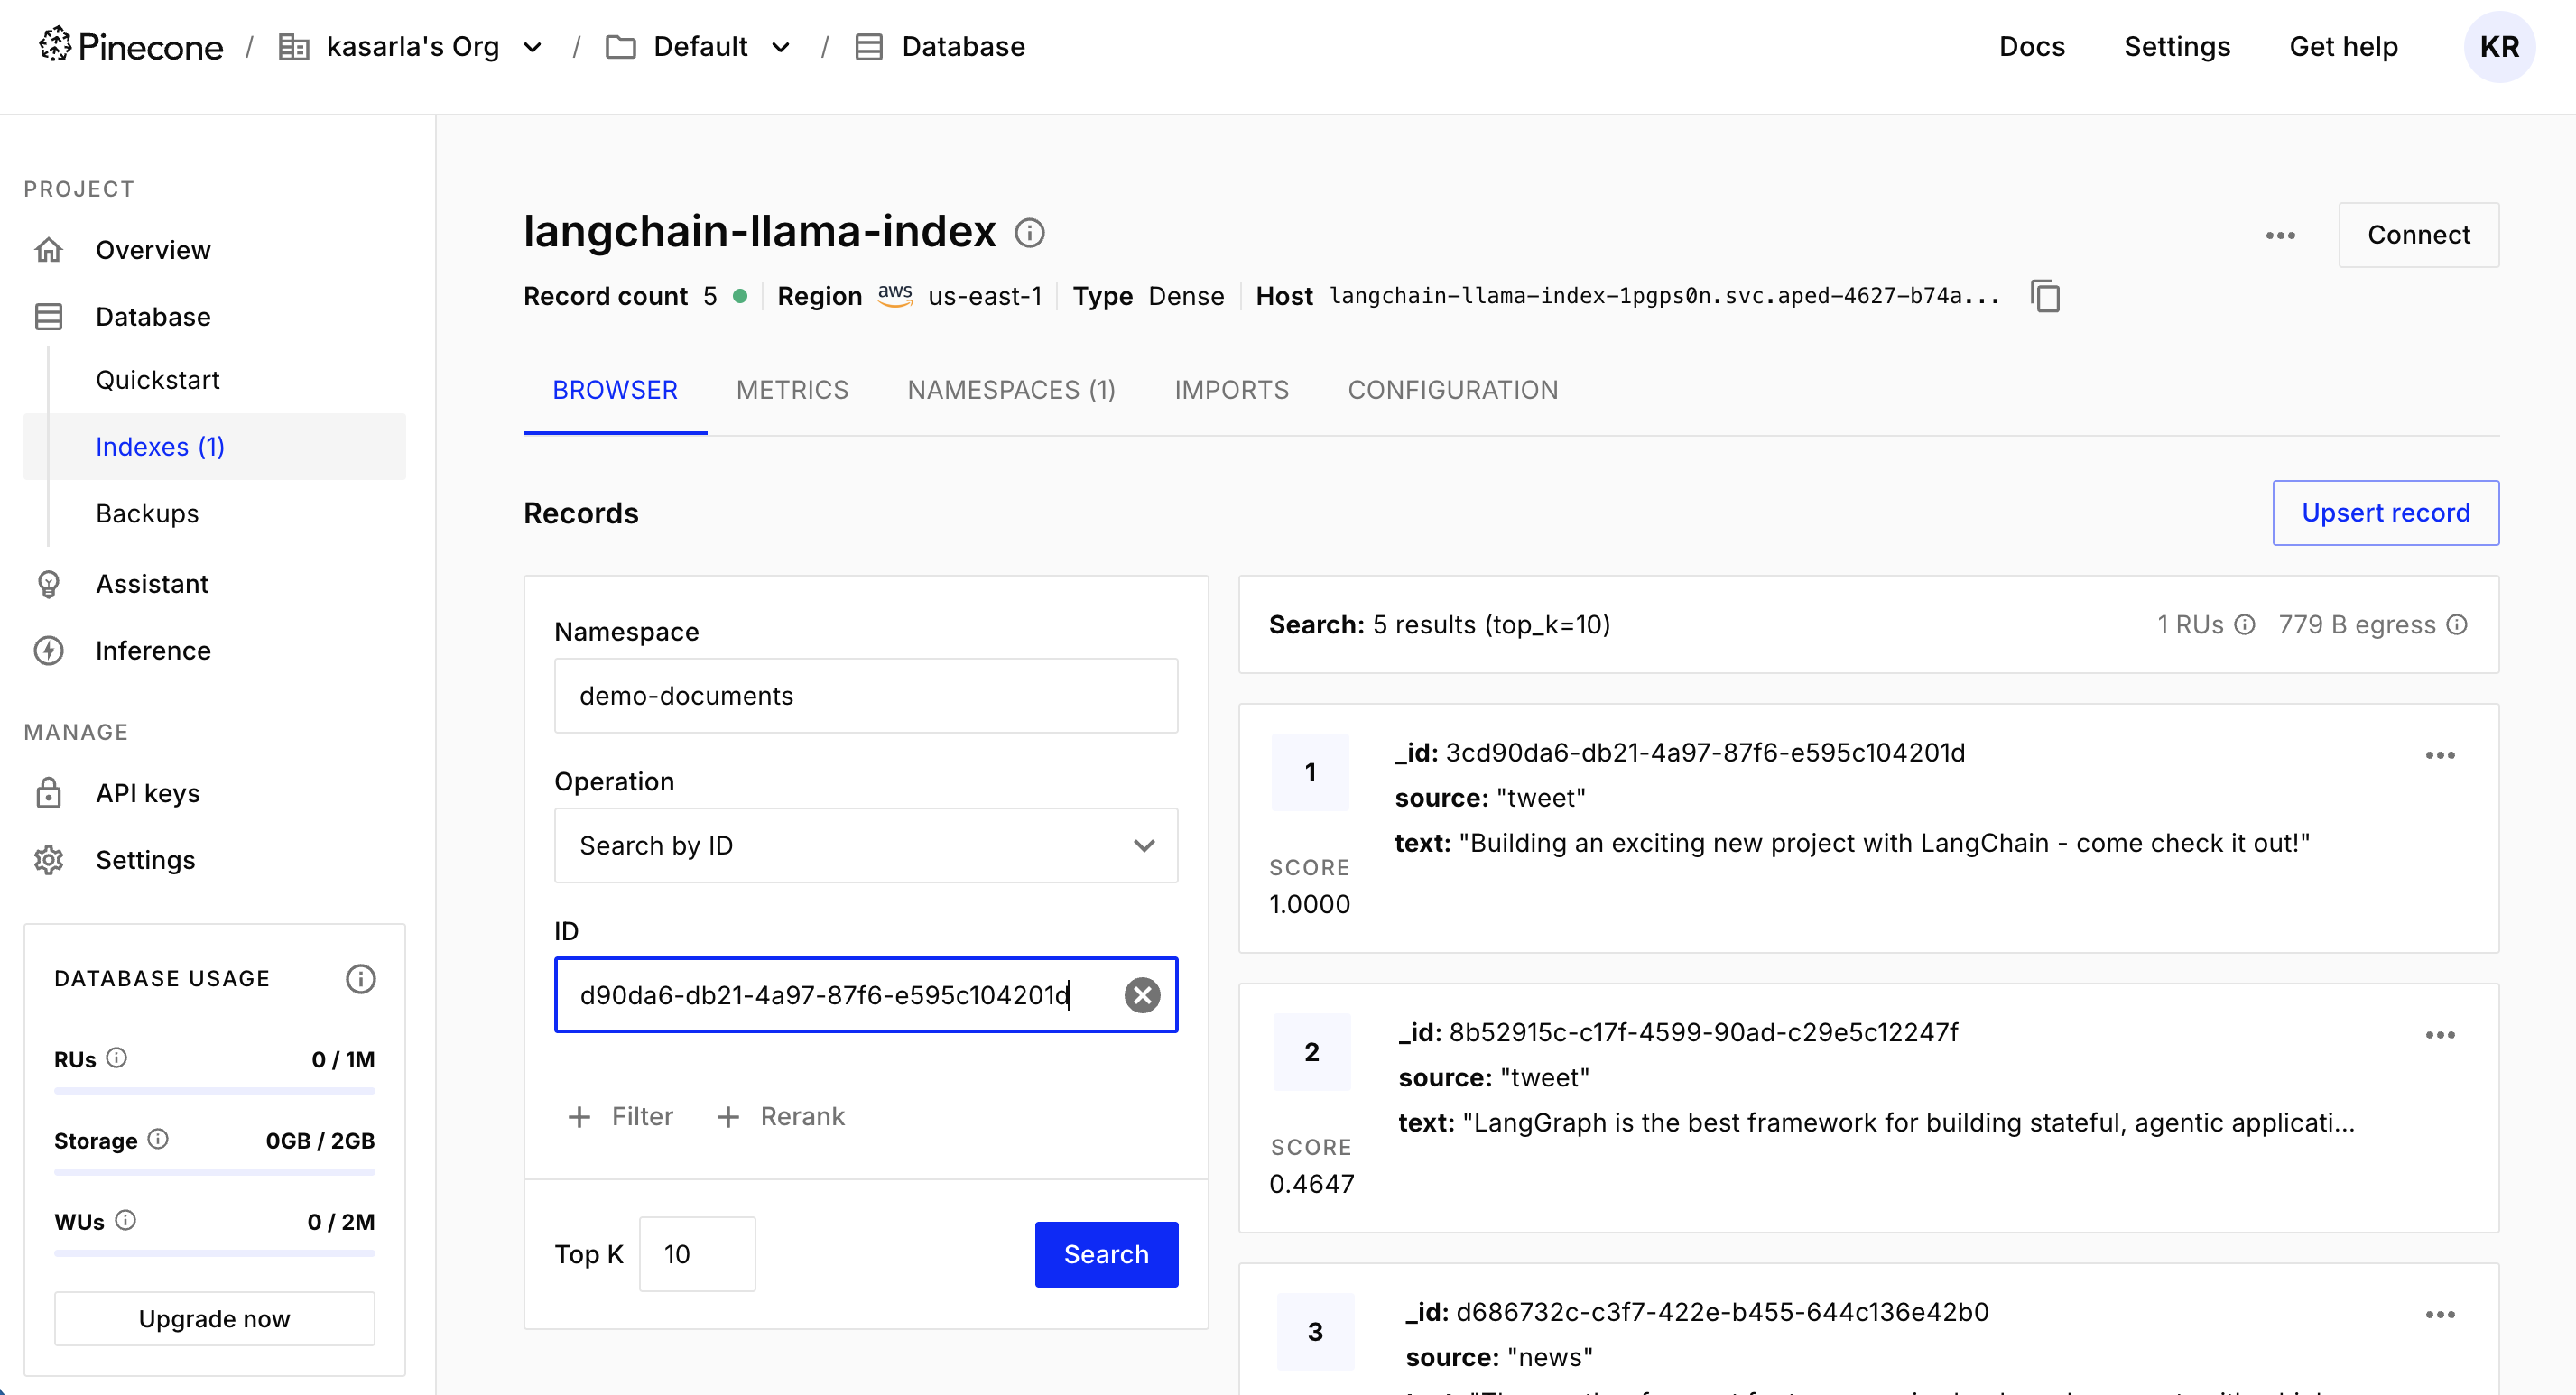

In [18]:
# ---------------------------------------------------
# 12. Delete a document
# ---------------------------------------------------

vector_store.delete(
    ids=[ids[-1]]
)